In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
def read_parquet_by_type(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
    purchase_history_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
    item_chunk_files = [file for file in files if 'item_chunk' in file]
    
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
    purchase_history_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_history_chunk_files]) if purchase_history_chunk_files else None
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
    
    # Trả về một dictionary chứa các DataFrame
    return {
        "user_chunk": user_chunk_df,
        "purchase_history_chunk": purchase_history_chunk_df,
        "item_chunk": item_chunk_df
    }

In [3]:
train_path = 'E:/KHMT2023_CS_UIT/05_C_Python_For_ML/recommendation_dataset'
dataframes = read_parquet_by_type(train_path)

In [4]:
df_user = dataframes["user_chunk"]
df_purchase = dataframes["purchase_history_chunk"]
df_item = dataframes["item_chunk"]

# Head information of each Chunk

In [5]:
print("User Chunk DataFrame:")
df_user.head()

User Chunk DataFrame:


customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7""","""e1e48206652bf8c279ff0206c69a80…",false
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức""","""77891759204bd27e69fb11a7b92889…",false
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre""","""b8041b584a0bb6655361727a0a6108…",false
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1""","""c52ceaca44a83ec41a219cfaff0e05…",false
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú""","""74ac5764f5d67d341aacf238d7762f…",false


In [6]:
print("Purchase Chunk DataFrame:")
df_purchase.head()

Purchase Chunk DataFrame:


timestamp,user_id,item_id,event_type,event_value,price,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,discount,is_deleted
i64,str,str,str,"decimal[38,4]","decimal[38,4]",i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,"decimal[38,4]",bool
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""","""Purchase""",1.0000,49000.0000,20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,0.0000,false
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""","""Purchase""",1.0000,69000.0000,20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,0.0000,false
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""","""Purchase""",2.0000,75000.0000,20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,0.0000,false
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""","""Purchase""",2.0000,58500.0000,20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,13000.0000,false
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""","""Purchase""",1.0000,89000.0000,20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,10000.0000,false


In [7]:
print("User Item DataFrame:")
df_item.head()

User Item DataFrame:


p_id,item_id,price,category_l1_id,category_l1,category_l2_id,category_l2,category_l3_id,category_l3,category_id,category,description,brand,manufacturer,creation_timestamp,is_deleted,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,image_url,gender_target,age_group,item_type,gp,weight,color,size,origin,volume,material,sale_status,description_new
i32,str,"decimal[38,4]",i32,str,i32,str,i32,str,i32,str,str,str,str,i64,bool,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,str,"decimal[38,4]",f32,str,str,str,str,str,i32,str
17065,"""0502020000004""",99000.0000,1,"""Babycare""",35,"""Bình sữa, phụ kiện""",7050,"""Núm ty""",7058,"""Núm ty Dr Brown""","""Không xác định""","""Dr.Brown's""","""Không xác định""",1333531544,false,2012-04-04 09:25:44.240,2025-08-18 09:59:19.847,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",36828.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Chi tiết sản phẩm …"
72370,"""0010290040150""",69000.0000,3292,"""Thời trang""",3958,"""Cơ cấu hàng cũ""",7007,"""Thời trang bé trai, bé gái cũ""",6987,"""Bộ quần áo bé gái""","""Không xác định""","""Con Cưng""","""Không xác định""",1503046250,false,2017-08-18 08:50:50.713,2025-09-18 16:05:42.360,null,null,null,"""Không xác định""","""Bé Gái""","""Từ 3Y""","""Bộ quần áo""",0.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Không xác định"""
31154,"""0008010000015""",45000.0000,351,"""Đồ chơi & Sách""",2033,"""0-1Y""",2118,"""Gặm nướu""",2121,"""Gặm nướu khác""","""- Chất liệu: Sản phẩm được làm…","""Thương hiệu khác""","""Không xác định""",1358501584,false,2013-01-18 09:33:04.260,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",14490.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Chi tiết sản phẩm …"
46123,"""0020010000094""",401000.0000,2222,"""Tã""",2272,"""Merries""",2275,"""Merries""",2276,"""Merries_Sơ Sinh""","""﻿﻿Tã dán Merries size S 82 miế…","""Merries Nhật""","""Không xác định""",1400062039,false,2014-05-14 10:07:19.603,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",59749.0000,null,"""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",0,"""Không xác định"""
46127,"""0020010000098""",401000.0000,2222,"""Tã""",2272,"""Merries""",2275,"""Merries""",2278,"""Merries_Tã Quần""","""﻿﻿﻿Bỉm tã quần Merries size M …","""Merries Nhật""","""Không xác định""",1400062040,false,2014-05-14 10:07:20.370,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",65764.0000,null,"""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",0,"""Không xác định"""


In [8]:
#print collumn names
print("User Chunk Columns:", df_user.columns)
print("Purchase Chunk Columns:", df_purchase.columns)
print("Item Chunk Columns:", df_item.columns)

User Chunk Columns: ['customer_id', 'gender', 'location', 'province', 'membership', 'timestamp', 'created_date', 'updated_date', 'sync_status_id', 'last_sync_date', 'sync_error_message', 'region', 'location_name', 'install_app', 'install_date', 'district', 'user_id', 'is_deleted']
Purchase Chunk Columns: ['timestamp', 'user_id', 'item_id', 'event_type', 'event_value', 'price', 'date_key', 'quantity', 'customer_id', 'created_date', 'updated_date', 'channel', 'payment', 'location', 'discount', 'is_deleted']
Item Chunk Columns: ['p_id', 'item_id', 'price', 'category_l1_id', 'category_l1', 'category_l2_id', 'category_l2', 'category_l3_id', 'category_l3', 'category_id', 'category', 'description', 'brand', 'manufacturer', 'creation_timestamp', 'is_deleted', 'created_date', 'updated_date', 'sync_status_id', 'last_sync_date', 'sync_error_message', 'image_url', 'gender_target', 'age_group', 'item_type', 'gp', 'weight', 'color', 'size', 'origin', 'volume', 'material', 'sale_status', 'description

In [9]:
import polars as pl
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Gộp dữ liệu cơ bản
df_price = (
    df_purchase
    .join(df_user.select(["user_id", "customer_id"]), on="user_id", how="left")
    .select(["customer_id", "created_date", "price"])
    .drop_nulls(["customer_id", "price"])
)

# Tổng tiền theo giao dịch (theo ngày)
df_price_txn = (
    df_price.group_by(["customer_id", "created_date"])
    .agg(pl.sum("price").alias("total_price_per_txn"))
)

# Trung bình theo khách hàng
df_avg_price = (
    df_price_txn.group_by("customer_id")
    .agg(pl.mean("total_price_per_txn").alias("avg_price_per_txn"))
)

# Chuẩn hóa và gom cụm
df_avg_price_pd = df_avg_price.to_pandas()
X = df_avg_price_pd[["avg_price_per_txn"]].fillna(0)
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df_avg_price_pd["cluster"] = kmeans.fit_predict(X_scaled)

# Gán nhãn cụm
cluster_order = (
    df_avg_price_pd.groupby("cluster")["avg_price_per_txn"]
    .mean()
    .sort_values()
    .index.tolist()
)
label_map = {
    cluster_order[0]: "Bình dân",
    cluster_order[1]: "Trung cấp",
    cluster_order[2]: "Cao cấp",
}
df_avg_price_pd["price_label"] = df_avg_price_pd["cluster"].map(label_map)

print(df_avg_price_pd.head())


   customer_id  avg_price_per_txn  cluster price_label
0      3883004           372750.0        1   Trung cấp
1      7392013           182000.0        0    Bình dân
2      7214644           170000.0        0    Bình dân
3      2918235            69000.0        0    Bình dân
4      8093792           439000.0        1   Trung cấp


In [10]:
# Gộp dữ liệu
df_category = (
    df_purchase
    .join(df_item.select(["item_id", "category_l1"]), on="item_id", how="left")
    .join(df_user.select(["user_id", "customer_id"]), on="user_id", how="left")
    .select(["customer_id", "created_date", "category_l1"])
    .drop_nulls(["customer_id", "category_l1"])
)

# Số loại sản phẩm trong mỗi giao dịch
df_category_txn = (
    df_category.group_by(["customer_id", "created_date"])
    .agg(pl.n_unique("category_l1").alias("num_categories_per_txn"))
)

# Trung bình số loại sản phẩm mỗi giao dịch
df_avg_category = (
    df_category_txn.group_by("customer_id")
    .agg(pl.mean("num_categories_per_txn").alias("avg_categories_per_txn"))
)

# Chuẩn hóa và gom cụm
df_avg_category_pd = df_avg_category.to_pandas()
X = df_avg_category_pd[["avg_categories_per_txn"]].fillna(0)
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df_avg_category_pd["cluster"] = kmeans.fit_predict(X_scaled)

# Gán nhãn cụm
cluster_order = (
    df_avg_category_pd.groupby("cluster")["avg_categories_per_txn"]
    .mean()
    .sort_values()
    .index.tolist()
)
label_map = {
    cluster_order[0]: "Mua ít",
    cluster_order[1]: "Mua vừa",
    cluster_order[2]: "Mua nhiều",
}
df_avg_category_pd["category_label"] = df_avg_category_pd["cluster"].map(label_map)

print(df_avg_category_pd.head())


   customer_id  avg_categories_per_txn  cluster category_label
0      8042169                5.000000        2      Mua nhiều
1      7592941                1.500000        1         Mua ít
2      5483605                1.671429        0        Mua vừa
3      1099250                1.655172        0        Mua vừa
4      7384671                1.000000        1         Mua ít


In [12]:
print(df_item["category_l1"].unique().to_list())


['Hóa mỹ phẩm gia đình', 'Phụ kiện', 'Textile', 'Sữa', 'Đồ chơi & Sách', 'Vệ sinh', 'Thời trang', 'Babycare', 'Hóa mỹ phẩm cho bé', 'Thực phẩm cho gia đình', 'TPCN', 'Gói Hội Viên', 'Thực phẩm cho bé', 'Tã', 'Sữa nước']


In [11]:
# Lọc mặt hàng sữa
df_milk = df_item.filter(pl.col("category_l1") == "Sữa")

# Gom nhóm giá sữa thành 3 nhóm
X = df_milk["price"].fill_null(0).to_numpy().reshape(-1, 1)
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df_milk = df_milk.with_columns(
    pl.Series(kmeans.fit_predict(X_scaled)).alias("price_cluster")
)

# Gán nhãn cụm giá sữa
cluster_order = (
    df_milk
    .group_by("price_cluster")
    .agg(pl.mean("price").alias("mean_price"))
    .sort("mean_price")
    .to_pandas()["price_cluster"]
    .tolist()
)
label_map = {cluster_order[0]: "Bình dân", cluster_order[1]: "Trung cấp", cluster_order[2]: "Cao cấp"}
df_milk = df_milk.with_columns(
    pl.col("price_cluster").map_elements(lambda x: label_map[x]).alias("milk_price_label")
)



# Thống kê nhãn mua nhiều nhất cho mỗi khách hàng
df_purchase_milk = (
    df_purchase.join(df_milk.select(["item_id", "milk_price_label"]), on="item_id", how="inner")
               .join(df_user.select(["user_id", "customer_id"]), on="user_id", how="left")
)

df_milk_label = (
    df_purchase_milk.group_by(["customer_id", "milk_price_label"])
                   .agg(pl.count("item_id").alias("count"))
                   .sort("count", descending=True)
                   .unique(subset=["customer_id"], keep="first")
)


C:\Users\huynh\AppData\Local\Temp\ipykernel_11076\3046188748.py:23: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("price_cluster").map_elements(lambda x: ...)
with this one instead:
  + pl.col("price_cluster").replace_strict(label_map)

  pl.col("price_cluster").map_elements(lambda x: label_map[x]).alias("milk_price_label")


In [12]:
# Lọc mặt hàng tã
df_diaper = df_item.filter(pl.col("category_l1") == "Tã")

# Gom nhóm giá tã thành 3 nhóm
X = df_diaper["price"].fill_null(0).to_numpy().reshape(-1, 1)
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df_diaper = df_diaper.with_columns(
    pl.Series(kmeans.fit_predict(X_scaled)).alias("price_cluster")
)

# Gán nhãn cụm giá
cluster_order = (
        df_diaper
        .group_by("price_cluster")
        .agg(pl.mean("price").alias("mean_price"))
        .sort("mean_price")  # sắp theo giá trung bình tăng dần
        .to_pandas()["price_cluster"]
        .tolist()
    )
label_map = {cluster_order[0]: "Bình dân", cluster_order[1]: "Trung cấp", cluster_order[2]: "Cao cấp"}
df_diaper = df_diaper.with_columns(
        pl.col("price_cluster").map_elements(lambda x: label_map[x]).alias("diaper_price_label")
    )
# Thống kê nhãn mua nhiều nhất cho mỗi khách hàng
df_purchase_diaper = (
    df_purchase.join(df_diaper.select(["item_id", "diaper_price_label"]), on="item_id", how="inner")
               .join(df_user.select(["user_id", "customer_id"]), on="user_id", how="left")
)

df_diaper_label = (
    df_purchase_diaper.group_by(["customer_id", "diaper_price_label"])
                      .agg(pl.count("item_id").alias("count"))
                      .sort("count", descending=True)
                      .unique(subset=["customer_id"], keep="first")
)


C:\Users\huynh\AppData\Local\Temp\ipykernel_11076\2054073491.py:23: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("price_cluster").map_elements(lambda x: ...)
with this one instead:
  + pl.col("price_cluster").replace_strict(label_map)

  pl.col("price_cluster").map_elements(lambda x: label_map[x]).alias("diaper_price_label")


In [37]:
print(df_avg_pd.columns)

Index(['customer_id', 'avg_categories_per_txn', 'cluster', 'category_label'], dtype='object')


In [14]:
final_features = (
    df_user.select(["customer_id"])
    .join(pl.from_pandas(df_avg_price_pd[["customer_id", "price_label"]]), on="customer_id", how="left")
    .join(pl.from_pandas(df_avg_category_pd[["customer_id", "category_label"]]), on="customer_id", how="left")
    .join(df_milk_label.select(["customer_id", "milk_price_label"]), on="customer_id", how="left")
    .join(df_diaper_label.select(["customer_id", "diaper_price_label"]), on="customer_id", how="left")
)

In [15]:
print("Final Features DataFrame:")
print(final_features.head(50))

Final Features DataFrame:
shape: (50, 5)
┌─────────────┬─────────────┬────────────────┬──────────────────┬────────────────────┐
│ customer_id ┆ price_label ┆ category_label ┆ milk_price_label ┆ diaper_price_label │
│ ---         ┆ ---         ┆ ---            ┆ ---              ┆ ---                │
│ i32         ┆ str         ┆ str            ┆ str              ┆ str                │
╞═════════════╪═════════════╪════════════════╪══════════════════╪════════════════════╡
│ 14732       ┆ Bình dân    ┆ Mua ít         ┆ null             ┆ null               │
│ 15126       ┆ Trung cấp   ┆ Mua vừa        ┆ null             ┆ Trung cấp          │
│ 29718       ┆ Bình dân    ┆ Mua ít         ┆ Bình dân         ┆ null               │
│ 30077       ┆ Trung cấp   ┆ Mua ít         ┆ null             ┆ Trung cấp          │
│ 30085       ┆ Bình dân    ┆ Mua ít         ┆ null             ┆ null               │
│ …           ┆ …           ┆ …              ┆ …                ┆ …                  │
│ 

# Test

In [30]:
import polars as pl
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [31]:
# 1️⃣ Gộp thông tin sản phẩm vào purchase để có category_l1
df = (
    df_purchase
    .join(df_item.select(["item_id", "category_l1"]), on="item_id", how="left")
    .join(df_user.select(["user_id", "customer_id"]), on="user_id", how="left")
    .select(["customer_id", "created_date", "category_l1"])
    .drop_nulls(["customer_id", "category_l1"])
)

In [27]:
print(df.shape)

(35729825, 2)


In [32]:
# 2️⃣ Đếm số loại sản phẩm trong mỗi giao dịch (một khách hàng trong một ngày)
df_txn = (
    df.group_by(["customer_id", "created_date"])
      .agg(pl.n_unique("category_l1").alias("num_categories_per_txn"))
)

In [33]:
# 3️⃣ Tính trung bình số loại sản phẩm / giao dịch cho mỗi khách hàng
df_avg = (
    df_txn.group_by("customer_id")
          .agg(pl.mean("num_categories_per_txn").alias("avg_categories_per_txn"))
)

In [34]:
# 4️⃣ Gom cụm 3 nhóm (KMeans)
df_avg_pd = df_avg.to_pandas()
X = df_avg_pd[["avg_categories_per_txn"]].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df_avg_pd["cluster"] = kmeans.fit_predict(X_scaled)

In [35]:
# 5️⃣ Gán nhãn "Mua ít" / "Mua vừa" / "Mua nhiều"
cluster_order = (
    df_avg_pd.groupby("cluster")["avg_categories_per_txn"]
    .mean()
    .sort_values()
    .index.tolist()
)

label_map = {
    cluster_order[0]: "Mua ít",
    cluster_order[1]: "Mua vừa",
    cluster_order[2]: "Mua nhiều"
}
df_avg_pd["avg_category_label"] = df_avg_pd["cluster"].map(label_map)

In [37]:
# 6️⃣ Kết quả
result = df_avg_pd[["customer_id", "avg_categories_per_txn", "avg_category_label"]]
result = result.sort_values(by="customer_id").reset_index(drop=True)

print(result.head())

# (Tùy chọn) Lưu kết quả
result.to_csv("customer_avg_category_clusters.csv", index=False)

   customer_id  avg_categories_per_txn avg_category_label
0        14732                1.000000             Mua ít
1        15126                1.750000            Mua vừa
2        17212                1.428571             Mua ít
3        17224                1.000000             Mua ít
4        17266                1.000000             Mua ít


In [38]:
summary = (
    result.groupby("avg_category_label")["avg_categories_per_txn"]
    .agg(["min", "max", "mean", "count"])
    .sort_values("min")
    .round(2)
)

print(summary)


                     min    max  mean    count
avg_category_label                            
Mua ít              1.00   1.53  1.11  1672696
Mua vừa             1.53   2.71  1.95   643344
Mua nhiều           2.71  11.00  3.47   126266


In [40]:
print(result.head(50))

    customer_id  avg_categories_per_txn avg_category_label
0         14732                1.000000             Mua ít
1         15126                1.750000            Mua vừa
2         17212                1.428571             Mua ít
3         17224                1.000000             Mua ít
4         17266                1.000000             Mua ít
5         17286                3.000000          Mua nhiều
6         17309                1.000000             Mua ít
7         17412                1.000000             Mua ít
8         28858                2.000000            Mua vừa
9         28879                1.588235            Mua vừa
10        28970                2.000000            Mua vừa
11        28986                2.000000            Mua vừa
12        28988                3.000000          Mua nhiều
13        29002                2.000000            Mua vừa
14        29041                1.666667            Mua vừa
15        29103                2.000000            Mua v

In [41]:
import polars as pl

eda_summary = (
    df_avg
    .select([
        pl.col("avg_categories_per_txn").mean().alias("mean"),
        pl.col("avg_categories_per_txn").std().alias("std"),
        pl.col("avg_categories_per_txn").min().alias("min"),
        pl.col("avg_categories_per_txn").max().alias("max"),
        pl.col("avg_categories_per_txn").count().alias("count")
    ])
)

print("📊 EDA đơn biến cho avg_categories_per_txn:")
print(eda_summary)


📊 EDA đơn biến cho avg_categories_per_txn:
shape: (1, 5)
┌──────────┬──────────┬─────┬──────┬─────────┐
│ mean     ┆ std      ┆ min ┆ max  ┆ count   │
│ ---      ┆ ---      ┆ --- ┆ ---  ┆ ---     │
│ f64      ┆ f64      ┆ f64 ┆ f64  ┆ u32     │
╞══════════╪══════════╪═════╪══════╪═════════╡
│ 1.452606 ┆ 0.656697 ┆ 1.0 ┆ 11.0 ┆ 2442306 │
└──────────┴──────────┴─────┴──────┴─────────┘


In [42]:
eda_by_label = (
    result.groupby("avg_category_label")["avg_categories_per_txn"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
    .sort_values("mean")
)

print("📊 EDA theo từng nhóm mua hàng:")
print(eda_by_label)


📊 EDA theo từng nhóm mua hàng:
                      count  mean   std   min    max
avg_category_label                                  
Mua ít              1672696  1.11  0.18  1.00   1.53
Mua vừa              643344  1.95  0.25  1.53   2.71
Mua nhiều            126266  3.47  0.85  2.71  11.00


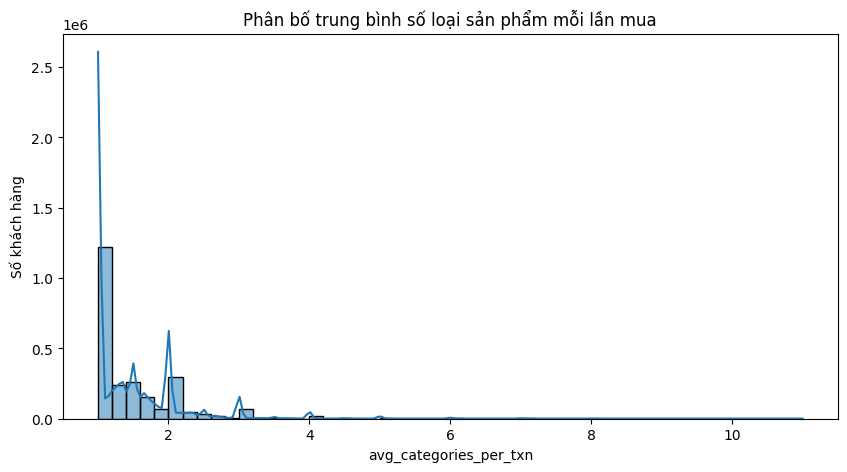

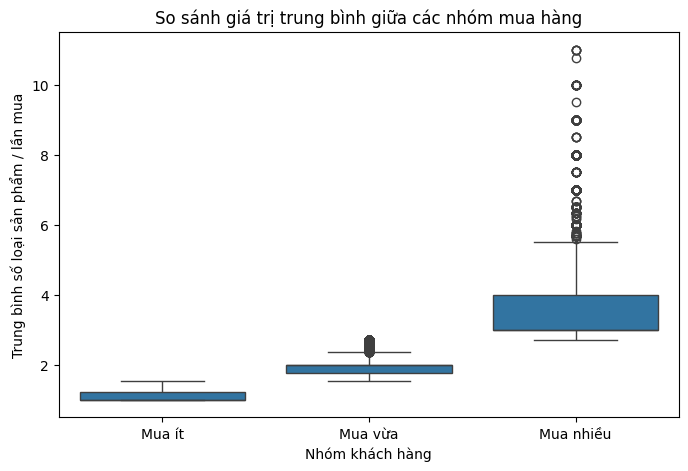

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(data=result, x="avg_categories_per_txn", kde=True, bins=50)
plt.title("Phân bố trung bình số loại sản phẩm mỗi lần mua")
plt.xlabel("avg_categories_per_txn")
plt.ylabel("Số khách hàng")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=result,
    x="avg_category_label",
    y="avg_categories_per_txn",
    order=["Mua ít", "Mua vừa", "Mua nhiều"],
)
plt.title("So sánh giá trị trung bình giữa các nhóm mua hàng")
plt.xlabel("Nhóm khách hàng")
plt.ylabel("Trung bình số loại sản phẩm / lần mua")
plt.show()
